# Trilytics MAI — District Market Attractiveness Index
**Executes [docs/MAI_MODEL_PLAN.md](../docs/MAI_MODEL_PLAN.md)** · data source: Cloud Firestore (project `medicine-attractive-index`) · output: new Firestore collection **`mai_scores`** (+ `mai_runs`) · models saved to `Saved_models/` (joblib).

Pipeline: crosswalk → feature matrix → EDA → hypothesis tests → composite index (OECD/JRC-aligned) → robustness → segmentation → multi-model ML (proxy-demand validation + MAI surrogate) → publish.

**Data-vintage caveats** (carried from the plan): NFHS rounds are 2014-15 & 2019-20 (no district survey exists in between; NFHS-6 2023-24 released 2026-05 but not yet machine-readable); SECC/Census are 2011 structural signals; TB & PMJAY are current-year live signals.

In [1]:
import json, math, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=0.85)
pd.set_option('display.max_columns', 60)
RNG = np.random.RandomState(42)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SAVED = ROOT / 'Saved_models'; SAVED.mkdir(exist_ok=True)
INTERIM = ROOT / 'data' / 'interim'; INTERIM.mkdir(parents=True, exist_ok=True)
MODEL_VERSION = 'mai_v1_2026-07-17'
print('root:', ROOT)

root: /Users/hrishavmajumder/Documents/Trylitics


In [2]:
# Firestore client (Admin SDK — same credentials as the pipeline)
import firebase_admin
from firebase_admin import credentials, firestore
if not firebase_admin._apps:
    cred = credentials.Certificate(str(ROOT / 'Credentials' / 'Firebase_Service_Account.json'))
    firebase_admin.initialize_app(cred)
db = firestore.client()

def load_collection(name):
    docs = {d.id: d.to_dict() for d in db.collection(name).stream()}
    print(f'{name:22s} {len(docs)} docs')
    return docs

fs_ind   = load_collection('district_indicators')
fs_dist  = load_collection('districts')
fs_pca   = load_collection('census_pca')
fs_secc  = load_collection('secc')
fs_tb    = load_collection('tb_live')
fs_pmjay = load_collection('pmjay_hospitals')

district_indicators    698 docs
districts              698 docs
census_pca             728 docs
secc                   631 docs
tb_live                36 docs
pmjay_hospitals        40 docs


## Phase 1 — District crosswalk (`dim_district`)
Spine = IDP district codes (shared by `district_indicators`, `census_pca`, `secc` — verified in-pipeline). The name-keyed sources (`tb_live`, `pmjay_hospitals`) are matched **within state** after normalization; Ni-kshay municipal-corporation splits ("Akola MC") are merged into their parent district. Unmatched entries are reported, never silently dropped. The `nfhs5_factsheet` collection is *excluded* from the feature matrix (names-only join adds risk without adding an indicator the IDP table lacks) — it remains in Firestore for the app.

In [3]:
def norm_name(s):
    s = str(s).lower().strip()
    s = s.replace('&', 'and')
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def norm_state(s):
    x = norm_name(s)
    aliases = {
        'nct of delhi': 'delhi', 'delhi ut': 'delhi',
        'jammu and kashmir ut': 'jammu and kashmir',
        'andaman and nicobar island': 'andaman and nicobar islands',
        'pondicherry': 'puducherry', 'orissa': 'odisha',
        'chattisgarh': 'chhattisgarh', 'uttaranchal': 'uttarakhand',
    }
    return aliases.get(x, x)

# spine rows from district_indicators (has names+codes), extended by census_pca
spine = {}
for code_, d in fs_ind.items():
    spine[code_] = {'district_code': code_, 'district_name': d.get('district_name'),
                    'state_name': d.get('state_name'), 'in_nfhs': True}
for code_, d in fs_pca.items():
    r = spine.setdefault(code_, {'district_code': code_, 'in_nfhs': False})
    r.setdefault('district_name', d.get('district_name'))
    r.setdefault('state_name', d.get('state_name'))
    r['in_pca'] = True
for code_ in fs_secc:
    if code_ in spine:
        spine[code_]['in_secc'] = True
dim = pd.DataFrame(spine.values())
dim['in_pca'] = dim['district_code'].isin(fs_pca.keys())
dim['in_secc'] = dim['district_code'].isin(fs_secc.keys())
dim['nname'] = dim['district_name'].map(norm_name)
dim['nstate'] = dim['state_name'].map(norm_state)
print(dim.shape); dim[['in_nfhs','in_pca','in_secc']].sum()

(735, 8)


in_nfhs    698
in_pca     728
in_secc    534
dtype: int64

In [4]:
from difflib import get_close_matches

def match_named_source(state_docs, label_fn, merge_mc=False):
    """{spine_code: value} by matching (state, name) into the spine."""
    matched, unmatched = {}, []
    by_state = {st: g for st, g in dim.groupby('nstate')}
    for sid, doc in state_docs.items():
        if sid.startswith('_'):
            continue
        st = norm_state(doc.get('state', sid.replace('_', ' ')))
        g = by_state.get(st)
        if g is None:
            unmatched.append((doc.get('state'), '<whole state>', 'state not in spine'))
            continue
        # optionally merge 'X MC' style rows into parent X before matching
        rows = {}
        for name, vals in doc['districts'].items():
            base = re.sub(r'\s+(mc|municipal corporation|corporation|mcorp)$', '',
                          norm_name(name)) if merge_mc else norm_name(name)
            rows.setdefault(base, []).append(vals)
        for base, vlist in rows.items():
            agg = {}
            for v in vlist:
                for k, x in v.items():
                    if isinstance(x, (int, float)):
                        agg[k] = agg.get(k, 0) + x
            hit = g[g['nname'] == base]
            if hit.empty:
                cand = get_close_matches(base, list(g['nname']), n=1, cutoff=0.85)
                if cand:
                    hit = g[g['nname'] == cand[0]]
            if hit.empty:
                unmatched.append((doc.get('state'), base, 'no name match'))
            else:
                codek = hit.iloc[0]['district_code']
                prev = matched.get(codek, {})
                for k, x in agg.items():
                    prev[k] = prev.get(k, 0) + x
                matched[codek] = prev
    return matched, unmatched

tb_by_code, tb_unmatched = match_named_source(fs_tb, None, merge_mc=True)
pm_by_code, pm_unmatched = match_named_source(fs_pmjay, None, merge_mc=False)
print(f'tb_live matched -> {len(tb_by_code)} districts; unmatched labels: {len(tb_unmatched)}')
print(f'pmjay   matched -> {len(pm_by_code)} districts; unmatched labels: {len(pm_unmatched)}')
pd.DataFrame(tb_unmatched + pm_unmatched, columns=['state','label','why']) \
  .to_csv(INTERIM / 'crosswalk_unmatched.csv', index=False)
pd.DataFrame(tb_unmatched + pm_unmatched, columns=['state','label','why']).head(12)

tb_live matched -> 640 districts; unmatched labels: 163
pmjay   matched -> 687 districts; unmatched labels: 77


,state,label,why
0,Andaman & Nicobar Islands,andamans and nicobars,no name match
1,Andhra Pradesh,nandyal,no name match
2,Andhra Pradesh,eluru,no name match
3,Andhra Pradesh,kakinada,no name match
4,Andhra Pradesh,ntr,no name match
5,Andhra Pradesh,alluri sitharama raju,no name match
6,Andhra Pradesh,markapuram,no name match
7,Andhra Pradesh,tirupati,no name match
8,Andhra Pradesh,anakapalli,no name match
9,Andhra Pradesh,sri sathya sai,no name match


In [5]:
dim['in_tb'] = dim['district_code'].isin(tb_by_code)
dim['in_pmjay'] = dim['district_code'].isin(pm_by_code)
dim.to_csv(INTERIM / 'dim_district.csv', index=False)
cov = dim[['in_nfhs','in_pca','in_secc','in_tb','in_pmjay']].mean().mul(100).round(1)
print('spine coverage %:'); print(cov)

spine coverage %:
in_nfhs     95.0
in_pca      99.0
in_secc     72.7
in_tb       87.1
in_pmjay    93.5
dtype: float64


## Phase 2 — Feature matrix
Indicators per pillar (direction: `+1` raises attractiveness, `-1` lowers). Rates are per-lakh using Census-PCA population. Momentum = NFHS `2019_20 − 2014_15` deltas. Imputation: within-state median, only where <⅓ of the pillar is missing for that district; every imputed cell flagged.

In [6]:
NF5, NF4 = '2019_20', '2014_15'
# (field, direction) — P2c chronic burden, P2a acute burden, P3 access, P4 affordability
NFHS_MAP = {
 'P2c': [('wom_bld_sugar_high', +1), ('men_bld_sugar_high', +1),
         ('wom_bp_ele_med', +1), ('men_bp_ele_med', +1),
         ('wom_obese', +1), ('wom_wh_ratio', +1),
         ('tobaco_men_15', +1), ('alcohol_men_15', +1)],
 'P2a': [('child_6_59_anemic', +1), ('wom_15_49_anaemic', +1),
         ('cd_ari_2wks', +1), ('cd_drh_2wks', +1),
         ('child_5_stunted', +1), ('child_5_underweight', +1),
         ('pop_hh_dw', -1), ('pop_hh_sf', -1)],
 'P3':  [('dc_insti_births', +1), ('births_skill_personnel', +1),
         ('cv_12_23_full_vacc', +1), ('mc_anc_4', +1),
         ('cv_12_23_vac_private', +1)],
 'P4':  [('hh_hlth_ins_fs', +1), ('fem_literacy', +1),
         ('pop_hh_elec', +1), ('hh_fuel_cooking', +1),
         ('avg_delivery_exp_phf', +1)],
}
MOMENTUM_FIELDS = [('wom_bld_sugar_high', +1), ('wom_bp_ele_med', +1),
                   ('wom_obese', +1), ('hh_hlth_ins_fs', +1),
                   ('dc_insti_births', +1)]
# DATA-QUALITY FINDING (2026-07-18): NFHS-4 did not collect blood-sugar /
# elevated-BP-or-medication comparably; the source stores "not collected" as
# 0.0 (verified: exactly 0.0000 across all 569 paired districts). A delta
# against that fake zero would equal the 2019-20 LEVEL, double-counting
# chronic burden inside the momentum pillar. Those NFHS-4 zeros are treated
# as missing; their deltas then fail the 80% coverage rule and drop out.
NFHS4_ZERO_MEANS_MISSING = {'wom_bld_sugar_high', 'wom_bp_ele_med'}

rows = []
for _, r in dim.iterrows():
    c = r['district_code']
    row = {'district_code': c, 'district_name': r['district_name'],
           'state_name': r['state_name']}
    nf = (fs_ind.get(c) or {}).get('nfhs', {})
    f5, f4 = nf.get(NF5, {}), nf.get(NF4, {})
    for pillar, fields in NFHS_MAP.items():
        for f, _ in fields:
            row[f] = f5.get(f)
    for f, _ in MOMENTUM_FIELDS:
        v5, v4 = f5.get(f), f4.get(f)
        if f in NFHS4_ZERO_MEANS_MISSING and v4 == 0:
            v4 = None
        row['d_' + f] = (v5 - v4) if (v5 is not None and v4 is not None) else None
    pca = fs_pca.get(c) or {}
    pop = pca.get('population_2011_total')
    row['population'] = pop
    urb = pca.get('pop_urban_total'); tot = pop
    row['urban_share'] = (urb / tot * 100) if (urb and tot) else None
    row['pop_below_15'] = f5.get('pop_below_15')
    secc = (fs_secc.get(c) or {}).get('categories', {}).get('all', {})
    th = secc.get('tot_hh')
    if th:
        row['inc_gt10k_share'] = (secc.get('mon_inc_gt_10k') or 0) / th * 100
        row['deprivation_share'] = (secc.get('hh_considered_deprivation') or 0) / th * 100
        row['vehicle_share'] = (secc.get('own_motor_vehicle') or 0) / th * 100
    tb = tb_by_code.get(c) or {}
    tb_tot = (tb.get('public') or 0) + (tb.get('private') or 0)
    if pop and tb_tot:
        row['tb_per_lakh'] = tb_tot / pop * 100000
        row['tb_private_share'] = (tb.get('private') or 0) / tb_tot * 100
    pm = pm_by_code.get(c) or {}
    pm_tot = (pm.get('public') or 0) + (pm.get('private') or 0)
    if pop and pm_tot:
        row['hosp_per_lakh'] = pm_tot / pop * 100000
        row['hosp_private_per_lakh'] = (pm.get('private') or 0) / pop * 100000
    rows.append(row)
feat = pd.DataFrame(rows).set_index('district_code')
print(feat.shape)
feat.head(3)

(735, 43)


,district_name,state_name,wom_bld_sugar_high,men_bld_sugar_high,wom_bp_ele_med,men_bp_ele_med,wom_obese,wom_wh_ratio,tobaco_men_15,alcohol_men_15,child_6_59_anemic,wom_15_49_anaemic,cd_ari_2wks,cd_drh_2wks,child_5_stunted,child_5_underweight,pop_hh_dw,pop_hh_sf,dc_insti_births,births_skill_personnel,cv_12_23_full_vacc,mc_anc_4,cv_12_23_vac_private,hh_hlth_ins_fs,fem_literacy,pop_hh_elec,hh_fuel_cooking,avg_delivery_exp_phf,d_wom_bld_sugar_high,d_wom_bp_ele_med,d_wom_obese,d_hh_hlth_ins_fs,d_dc_insti_births,population,urban_share,pop_below_15,tb_per_lakh,tb_private_share,hosp_per_lakh,hosp_private_per_lakh,inc_gt10k_share,deprivation_share,vehicle_share
district_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
001,Anantnag,Jammu And Kashmir,5.0,5.3,20.0,19.4,28.6,90.8,47.0,0.1,79.2,74.3,7.7,7.0,28.2,28.3,99.3,84.7,90.5,98.1,83.3,80.9,0.0,7.3,74.7,98.7,76.5,6058.0,None,None,-4.5,4.7,-0.7,1001544.0,28.245090,22.4,25.460689,5.490196,2.496146,1.697379,NaN,NaN,NaN
002,Budgam,Jammu And Kashmir,2.9,3.1,19.9,18.6,25.3,86.4,42.9,0.2,85.0,73.9,5.1,6.3,26.8,20.6,95.8,77.0,96.5,98.5,92.5,66.5,0.0,5.2,74.1,99.5,71.1,5525.0,None,None,-6.1,2.1,-0.6,671640.0,14.578048,22.3,NaN,NaN,2.084450,0.595557,NaN,NaN,NaN
003,Baramulla,Jammu And Kashmir,4.5,3.8,23.7,19.0,31.1,78.3,34.7,1.2,70.4,72.5,3.8,9.9,23.2,17.3,93.3,77.7,96.2,97.0,73.7,75.2,1.7,6.5,67.9,98.7,76.5,9853.0,None,None,6.6,5.9,2.4,987114.0,18.488239,24.8,18.032365,10.112360,1.519581,0.810443,NaN,NaN,NaN


In [7]:
PILLARS = {
 'P1_scale': {'log_population': +1, 'urban_share': +1, 'pop_below_15': +1},
 'P2_chronic': {f: d for f, d in NFHS_MAP['P2c']},
 'P2_acute': dict(list({f: d for f, d in NFHS_MAP['P2a']}.items())
                  + [('tb_per_lakh', +1)]),
 'P3_access': dict(list({f: d for f, d in NFHS_MAP['P3']}.items())
                   + [('hosp_per_lakh', +1), ('hosp_private_per_lakh', +1)]),
 'P4_afford': dict(list({f: d for f, d in NFHS_MAP['P4']}.items())
                   + [('inc_gt10k_share', +1), ('deprivation_share', -1),
                      ('vehicle_share', +1)]),
 'P5_momentum': {'d_' + f: d for f, d in MOMENTUM_FIELDS},
}
feat['log_population'] = np.log10(feat['population'].where(feat['population'] > 0))
ALL_IND = [f for p in PILLARS.values() for f in p]
missing_cols = [f for f in ALL_IND if f not in feat.columns]
assert not missing_cols, missing_cols

# JRC coverage rule: keep indicator if >=80% of NFHS-covered districts valid
base = feat[feat.index.isin(fs_ind.keys())]
coverage = base[ALL_IND].notna().mean().sort_values()
dropped = coverage[coverage < 0.80]
for f in dropped.index:
    for p in PILLARS.values():
        p.pop(f, None)
ALL_IND = [f for p in PILLARS.values() for f in p]
print(f'indicators kept: {len(ALL_IND)}; dropped (<80% coverage): {list(dropped.index) or "none"}')
if any(f in dropped.index for f in ('inc_gt10k_share', 'deprivation_share', 'vehicle_share')):
    print('NOTE: SECC-derived affordability fields fall below the JRC 80% '
          'coverage floor (SECC = 631 districts on 2011 boundaries vs 698 '
          'spine). P4 continues on NFHS/PCA indicators (insurance, literacy, '
          'electrification, clean fuel, delivery OOP). Documented limitation; '
          'future fix = parent-district inheritance per design doc §6.2.')
coverage.head(8)

indicators kept: 35; dropped (<80% coverage): ['d_wom_bp_ele_med', 'd_wom_bld_sugar_high', 'vehicle_share', 'deprivation_share', 'inc_gt10k_share']
NOTE: SECC-derived affordability fields fall below the JRC 80% coverage floor (SECC = 631 districts on 2011 boundaries vs 698 spine). P4 continues on NFHS/PCA indicators (insurance, literacy, electrification, clean fuel, delivery OOP). Documented limitation; future fix = parent-district inheritance per design doc §6.2.


d_wom_bp_ele_med        0.000000
d_wom_bld_sugar_high    0.000000
vehicle_share           0.756447
deprivation_share       0.756447
inc_gt10k_share         0.756447
d_dc_insti_births       0.815186
d_wom_obese             0.815186
d_hh_hlth_ins_fs        0.815186
dtype: float64

In [8]:
# analysis set = NFHS spine; impute within-state median with flags
X = base[ALL_IND].copy()
imputed = X.isna()
X = X.groupby(base['state_name']).transform(lambda s: s.fillna(s.median()))
X = X.fillna(X.median())  # last-resort national median
n_imp = int(imputed.values.sum())
print(f'districts: {len(X)}; imputed cells: {n_imp} '
      f'({n_imp / X.size * 100:.1f}% of matrix)')
meta = base[['district_name', 'state_name', 'population']].copy()
X.join(meta).to_csv(INTERIM / 'feature_matrix.csv')

districts: 698; imputed cells: 679 (2.8% of matrix)


## Phase 2b — EDA

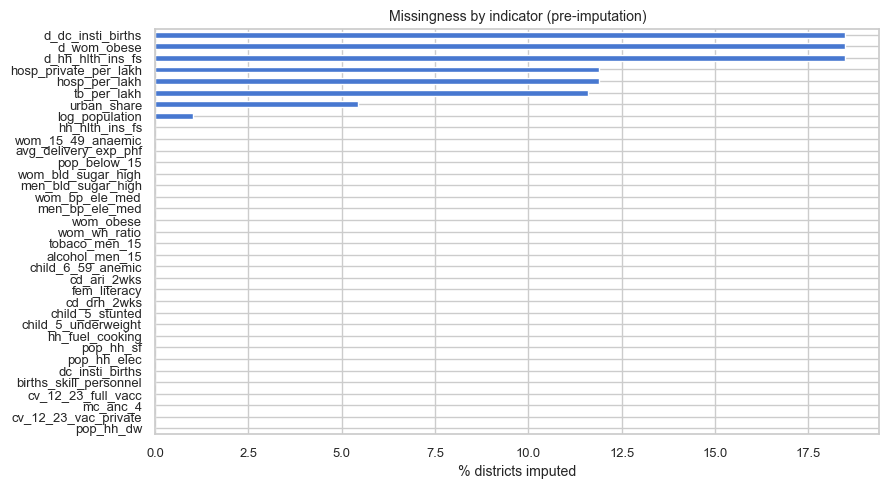

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
imputed[ALL_IND].mean().mul(100).sort_values().plot.barh(ax=ax, color='#4878d0')
ax.set_xlabel('% districts imputed'); ax.set_title('Missingness by indicator (pre-imputation)')
plt.tight_layout(); plt.show()

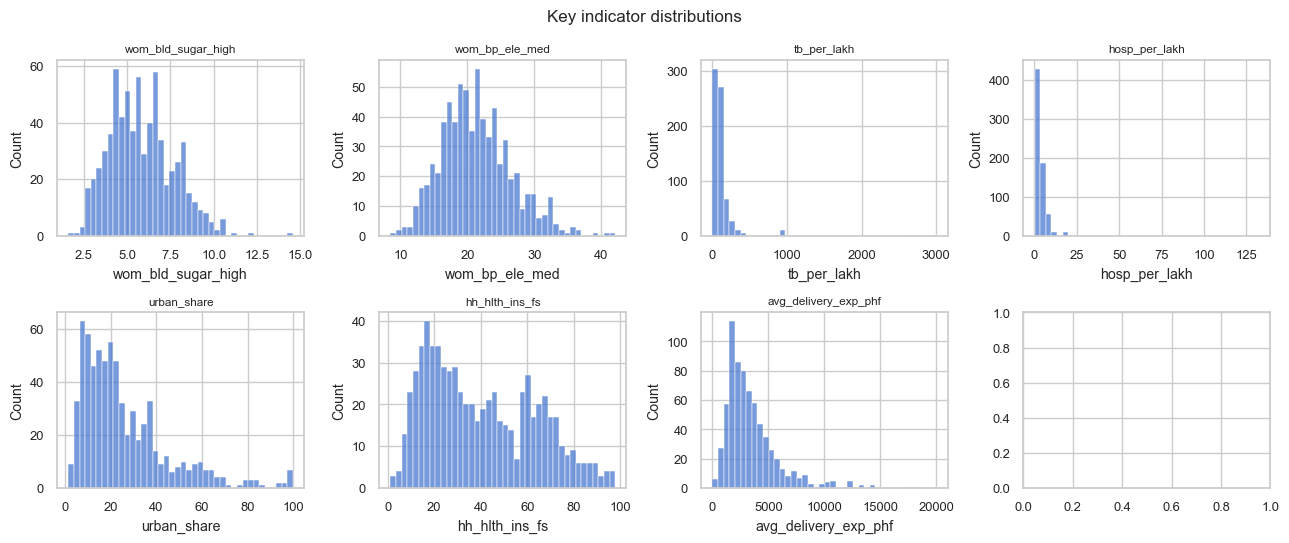

In [10]:
sel = [f for f in ['wom_bld_sugar_high', 'wom_bp_ele_med', 'tb_per_lakh',
                   'hosp_per_lakh', 'inc_gt10k_share', 'deprivation_share',
                   'urban_share', 'd_wom_bld_sugar_high', 'hh_hlth_ins_fs',
                   'avg_delivery_exp_phf'] if f in X.columns][:8]
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for a, f in zip(axes.flat, sel):
    sns.histplot(X[f], bins=40, ax=a, color='#4878d0')
    a.set_title(f, fontsize=8.5)
plt.suptitle('Key indicator distributions'); plt.tight_layout(); plt.show()

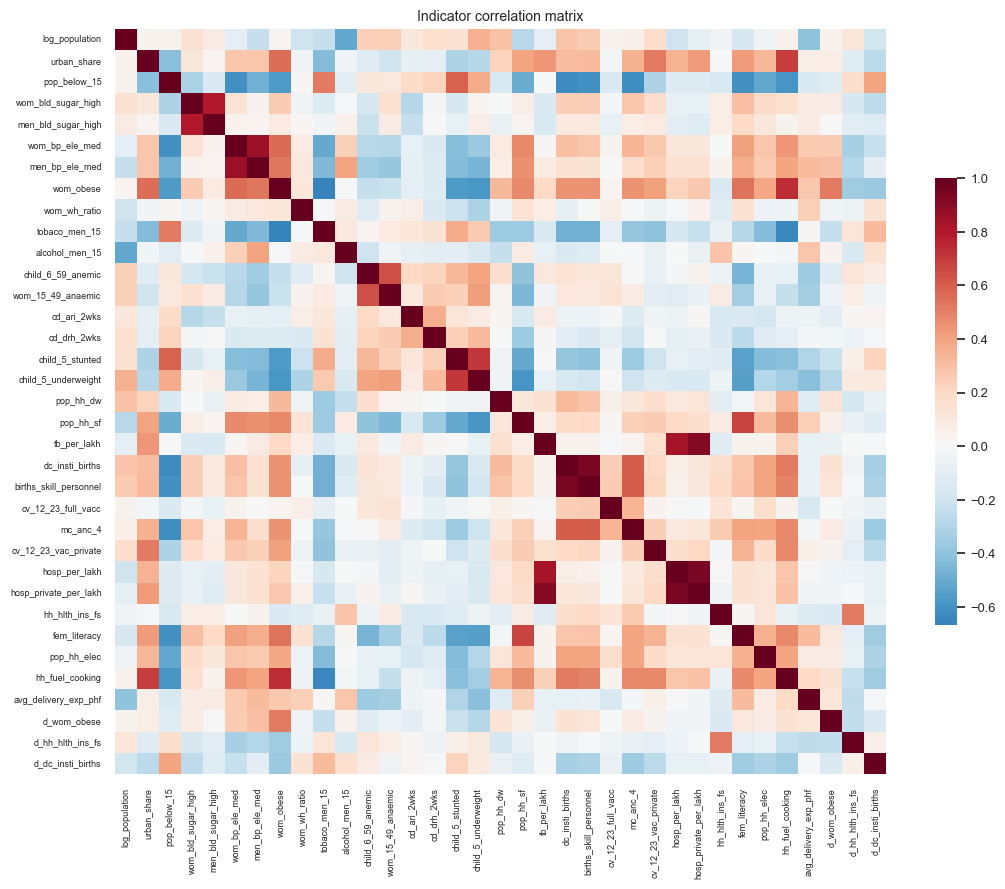

In [11]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(X.corr(), cmap='RdBu_r', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .6})
ax.tick_params(labelsize=6.5)
ax.set_title('Indicator correlation matrix'); plt.tight_layout(); plt.show()

## Phase 2c — Statistical screening & hypothesis tests
**Why no stationarity test:** ADF/KPSS assess whether a *time series'* distribution is time-invariant; they require a sequence of observations over time. This dataset is **cross-sectional** (≈700 districts) with exactly **two** survey time points — no admissible series exists, so a stationarity test would be misapplied statistics. The valid analogue questions are answered below: *did indicators shift between rounds?* (paired tests) and *are distributions well-behaved for normalization?* (normality + JRC outlier screening).

**Data-quality finding:** NFHS-4 stores *not collected* as `0.0` for the blood-sugar and elevated-BP indicators (exactly 0.0000 across every paired district). Naive deltas against that sentinel would equal the 2019-20 level and double-count chronic burden inside momentum — those zeros are treated as missing throughout this notebook.

In [12]:
# (1) Normality + JRC outlier screen (|skew|>2 & kurtosis>3.5 -> winsorize)
scr = []
for f in ALL_IND:
    v = X[f].dropna()
    k2, p = stats.normaltest(v)
    scr.append({'indicator': f, 'skew': stats.skew(v), 'kurtosis': stats.kurtosis(v),
                'dagostino_p': p,
                'winsorize': abs(stats.skew(v)) > 2 and stats.kurtosis(v) > 3.5})
screen = pd.DataFrame(scr).set_index('indicator').round(3)
print(f"non-normal at p<0.05: {(screen['dagostino_p'] < .05).sum()}/{len(screen)}  "
      f"| flagged for winsorizing: {int(screen['winsorize'].sum())}")
screen.sort_values('skew', ascending=False).head(10)

non-normal at p<0.05: 34/35  | flagged for winsorizing: 8


,skew,kurtosis,dagostino_p,winsorize
indicator,,,,
hosp_per_lakh,12.490,191.398,0.0,True
hosp_private_per_lakh,11.701,168.532,0.0,True
tb_per_lakh,9.443,119.787,0.0,True
avg_delivery_exp_phf,2.331,8.075,0.0,True
cv_12_23_vac_private,2.308,6.842,0.0,True
cd_drh_2wks,1.852,7.892,0.0,False
urban_share,1.539,2.531,0.0,False
d_dc_insti_births,1.234,2.324,0.0,False
cd_ari_2wks,1.098,0.983,0.0,False


In [13]:
# (2) Paired hypothesis tests: NFHS-4 -> NFHS-5 shifts (the momentum evidence)
tests = []
for f, _ in MOMENTUM_FIELDS:
    pairs = []
    for c, d in fs_ind.items():
        nf = d.get('nfhs', {})
        a, b = nf.get(NF4, {}).get(f), nf.get(NF5, {}).get(f)
        if f in NFHS4_ZERO_MEANS_MISSING and a == 0:
            continue  # NFHS-4 'not collected' sentinel — no valid pair
        if a is not None and b is not None:
            pairs.append((a, b))
    if not pairs:
        tests.append({'indicator': f, 'n_districts': 0,
                      'note': 'no comparable NFHS-4 baseline (see markdown)'})
        continue
    a = np.array([p[0] for p in pairs]); b = np.array([p[1] for p in pairs])
    t, tp = stats.ttest_rel(b, a)
    w, wp = stats.wilcoxon(b, a)
    tests.append({'indicator': f, 'n_districts': len(pairs),
                  'mean_2014_15': a.mean(), 'mean_2019_20': b.mean(),
                  'mean_delta': (b - a).mean(),
                  'paired_t_p': tp, 'wilcoxon_p': wp,
                  'significant_rise': tp < .05 and (b - a).mean() > 0})
pd.DataFrame(tests).set_index('indicator').round(4)

,n_districts,note,mean_2014_15,mean_2019_20,mean_delta,paired_t_p,wilcoxon_p,significant_rise
indicator,,,,,,,,
wom_bld_sugar_high,0,no comparable NFHS-4 baseline (see markdown),NaN,NaN,NaN,NaN,NaN,NaN
wom_bp_ele_med,0,no comparable NFHS-4 baseline (see markdown),NaN,NaN,NaN,NaN,NaN,NaN
wom_obese,569,NaN,18.5738,22.9800,4.4062,0.0,0.0,True
hh_hlth_ins_fs,569,NaN,25.3598,38.6359,13.2761,0.0,0.0,True
dc_insti_births,569,NaN,79.1220,88.8756,9.7536,0.0,0.0,True


In [14]:
# (3) Pillar coherence: mean |within-pillar correlation| per pillar
coh = {}
for p, fields in PILLARS.items():
    fl = [f for f in fields if f in X.columns]
    if len(fl) > 1:
        cm = X[fl].corr().abs().values
        coh[p] = cm[np.triu_indices_from(cm, 1)].mean()
print('mean |r| within pillar:')
pd.Series(coh).round(3)

mean |r| within pillar:


P1_scale       0.166
P2_chronic     0.230
P2_acute       0.223
P3_access      0.267
P4_afford      0.217
P5_momentum    0.147
dtype: float64

In [15]:
# (4) ANOVA: does chronic burden differ across region groups?
REGION = {'north': ['jammu and kashmir','ladakh','himachal pradesh','punjab','uttarakhand','haryana','delhi','rajasthan','chandigarh'],
          'central': ['uttar pradesh','madhya pradesh','chhattisgarh'],
          'east': ['bihar','jharkhand','odisha','west bengal'],
          'northeast': ['sikkim','arunachal pradesh','nagaland','manipur','mizoram','tripura','meghalaya','assam'],
          'west': ['gujarat','maharashtra','goa','dadra and nagar haveli','daman and diu'],
          'south': ['andhra pradesh','telangana','karnataka','kerala','tamil nadu','puducherry','lakshadweep','andaman and nicobar islands']}
s2r = {s: r for r, ss in REGION.items() for s in ss}
reg = base['state_name'].map(lambda s: s2r.get(norm_state(s), 'other'))
chronic_raw = X[[f for f in PILLARS['P2_chronic']]].mean(axis=1)
groups = [chronic_raw[reg == r].dropna() for r in REGION]
F, pv = stats.f_oneway(*groups)
print(f'one-way ANOVA chronic burden ~ region: F={F:.1f}, p={pv:.2e}')
chronic_raw.groupby(reg).mean().round(2).sort_values(ascending=False)

one-way ANOVA chronic burden ~ region: F=68.0, p=9.12e-58


state_name
northeast    29.28
east         26.07
south        25.96
north        25.41
other        23.80
central      23.56
west         21.71
dtype: float64

## Phase 3 — Composite index (winsorize → min-max 0–100 → pillar scores → weights → aggregate)
Headline: business budget-allocation pillar weights, weighted **arithmetic** mean (NITI Health Index convention). Companions: PCA & entropy weights, **geometric** aggregation — reported as robustness, per the plan.

In [16]:
Xw = X.copy()
for f in screen[screen['winsorize']].index:
    lo, hi = Xw[f].quantile([.025, .975])
    Xw[f] = Xw[f].clip(lo, hi)

DIR = {}
for p, fields in PILLARS.items():
    DIR.update(fields)
N = pd.DataFrame(index=Xw.index)
for f in ALL_IND:
    v = Xw[f]
    n = (v - v.min()) / (v.max() - v.min()) * 100
    N[f] = 100 - n if DIR[f] < 0 else n

pillar_scores = pd.DataFrame({p: N[[f for f in fields]].mean(axis=1)
                              for p, fields in PILLARS.items()})
pillar_scores.describe().round(1)

,P1_scale,P2_chronic,P2_acute,P3_access,P4_afford,P5_momentum
count,698.0,698.0,698.0,698.0,698.0,698.0
mean,41.2,38.6,34.9,50.3,51.4,40.8
std,8.4,7.7,9.3,12.5,13.7,6.8
min,10.1,20.6,9.5,11.5,11.0,14.7
25%,35.8,33.0,28.4,41.5,41.9,36.5
50%,41.0,38.1,34.8,50.1,52.3,39.6
75%,46.5,44.0,41.7,58.4,62.0,44.8
max,67.2,72.9,62.1,90.8,87.5,62.8


In [17]:
W_BUSINESS = {'P1_scale': .25, 'P2_chronic': .125, 'P2_acute': .125,
              'P3_access': .20, 'P4_afford': .15, 'P5_momentum': .15}

# data-driven weight sets
from sklearn.decomposition import PCA as skPCA
Z = (pillar_scores - pillar_scores.mean()) / pillar_scores.std()
pca = skPCA().fit(Z)
w_pca = np.abs(pca.components_[0]); w_pca = dict(zip(pillar_scores, w_pca / w_pca.sum()))
P = pillar_scores / 100
eps = 1e-9; Pn = (P + eps).div((P + eps).sum(axis=0), axis=1)
entropy = -(Pn * np.log(Pn)).sum(axis=0) / np.log(len(Pn))
dvg = 1 - entropy
w_ent = dict(dvg / dvg.sum())

def agg(ps, w, geometric=False):
    wv = np.array([w[c] for c in ps.columns])
    if geometric:
        return np.exp((np.log(ps.clip(lower=1)) * wv).sum(axis=1) / wv.sum())
    return (ps * wv).sum(axis=1) / wv.sum()

scores = pd.DataFrame(index=pillar_scores.index)
scores['mai_overall'] = agg(pillar_scores, W_BUSINESS)
scores['mai_overall_geom'] = agg(pillar_scores, W_BUSINESS, geometric=True)
scores['mai_pca_w'] = agg(pillar_scores, w_pca)
scores['mai_entropy_w'] = agg(pillar_scores, w_ent)

# therapy views: the excluded burden pillar's weight moves onto the kept one
wch = {'P1_scale': .25, 'P2_chronic': .25, 'P3_access': .20,
       'P4_afford': .15, 'P5_momentum': .15}
wac = {'P1_scale': .25, 'P2_acute': .25, 'P3_access': .20,
       'P4_afford': .15, 'P5_momentum': .15}
scores['mai_chronic'] = agg(pillar_scores[list(wch)], wch)
scores['mai_acute'] = agg(pillar_scores[list(wac)], wac)

W_FUT = dict(W_BUSINESS); W_FUT['P5_momentum'] = .30
tot = sum(W_FUT.values()); W_FUT = {k: v / tot for k, v in W_FUT.items()}
scores['mai_current'] = agg(pillar_scores[[c for c in pillar_scores if c != 'P5_momentum']],
                            {k: v for k, v in W_BUSINESS.items() if k != 'P5_momentum'})
scores['mai_future'] = agg(pillar_scores, W_FUT)

import scipy.stats as ss
print('rank correlation (Spearman) between weighting schemes:')
print(pd.DataFrame({
  'business_vs_pca':     [ss.spearmanr(scores.mai_overall, scores.mai_pca_w).statistic],
  'business_vs_entropy': [ss.spearmanr(scores.mai_overall, scores.mai_entropy_w).statistic],
  'arith_vs_geom':       [ss.spearmanr(scores.mai_overall, scores.mai_overall_geom).statistic],
}).round(3))
print('\nweights:', {k: round(v, 3) for k, v in W_BUSINESS.items()})
print('pca w  :', {k: round(v, 3) for k, v in w_pca.items()})
print('entropy:', {k: round(v, 3) for k, v in w_ent.items()})

rank correlation (Spearman) between weighting schemes:
   business_vs_pca  business_vs_entropy  arith_vs_geom
0            0.899                0.951          0.967

weights: {'P1_scale': 0.25, 'P2_chronic': 0.125, 'P2_acute': 0.125, 'P3_access': 0.2, 'P4_afford': 0.15, 'P5_momentum': 0.15}
pca w  : {'P1_scale': 0.077, 'P2_chronic': 0.196, 'P2_acute': 0.216, 'P3_access': 0.174, 'P4_afford': 0.243, 'P5_momentum': 0.094}
entropy: {'P1_scale': 0.134, 'P2_chronic': 0.121, 'P2_acute': 0.232, 'P3_access': 0.191, 'P4_afford': 0.236, 'P5_momentum': 0.086}


In [18]:
for c in ['mai_overall', 'mai_chronic', 'mai_acute', 'mai_current', 'mai_future']:
    scores[c.replace('mai', 'rank')] = scores[c].rank(ascending=False).astype(int)
scores['tier'] = pd.qcut(scores['mai_overall'], 4, labels=['D', 'C', 'B', 'A'])
scores['growth_flag'] = ((pillar_scores['P5_momentum'] >
                          pillar_scores['P5_momentum'].quantile(.75)) &
                         (scores['rank_overall'] > 100)).map(bool)
top = scores.join(meta).nlargest(15, 'mai_overall')
top[['district_name', 'state_name', 'mai_overall', 'mai_chronic', 'mai_acute',
     'rank_overall', 'tier']].round(1)

,district_name,state_name,mai_overall,mai_chronic,mai_acute,rank_overall,tier
district_code,,,,,,,
078,East,Delhi,58.6,58.7,58.5,1,A
082,North West,Delhi,58.2,58.0,58.4,2,A
085,West,Delhi,58.1,57.8,58.5,3,A
083,South,Delhi,57.7,59.0,56.5,4,A
081,North East,Delhi,57.7,58.2,57.2,5,A
568,Chennai,Tamil Nadu,57.6,61.5,53.7,6,A
670,South East,Delhi,57.2,57.2,57.1,7,A
079,New Delhi,Delhi,56.8,56.9,56.7,8,A
569,Coimbatore,Tamil Nadu,56.0,59.9,52.1,9,A


## Phase 4 — Robustness (Monte-Carlo weight perturbation, method swaps, leave-one-out)

In [19]:
n_mc = 500
ranks_mc = np.zeros((n_mc, len(scores)))
keys = list(W_BUSINESS)
for i in range(n_mc):
    w = {k: W_BUSINESS[k] * RNG.uniform(.75, 1.25) for k in keys}
    s = agg(pillar_scores, w)
    ranks_mc[i] = s.rank(ascending=False).values
rank_lo = np.percentile(ranks_mc, 5, axis=0)
rank_hi = np.percentile(ranks_mc, 95, axis=0)
scores['rank_lo_p5'] = rank_lo.astype(int); scores['rank_hi_p95'] = rank_hi.astype(int)

top50 = set(scores.nsmallest(50, 'rank_overall').index)
stab = np.mean([len(top50 & set(scores.index[np.argsort(ranks_mc[i])][:50])) / 50
                for i in range(n_mc)])
print(f'top-50 membership stability across ±25% weight perturbation: {stab:.1%}')

# leave-one-indicator-out max rank shift
shifts = {}
for f in ALL_IND:
    ps2 = pd.DataFrame({p: N[[x for x in fl if x != f]].mean(axis=1)
                        for p, fl in PILLARS.items() if [x for x in fl if x != f]})
    s2 = agg(ps2, {k: W_BUSINESS[k] for k in ps2.columns})
    shifts[f] = (s2.rank(ascending=False) - scores['rank_overall']).abs().max()
loio = pd.Series(shifts).sort_values(ascending=False)
print('most rank-influential indicators (max |rank shift| when dropped):')
loio.head(5)

top-50 membership stability across ±25% weight perturbation: 95.2%
most rank-influential indicators (max |rank shift| when dropped):


urban_share          488.0
log_population       312.0
d_dc_insti_births    216.0
d_hh_hlth_ins_fs     209.0
pop_below_15         187.0
dtype: float64

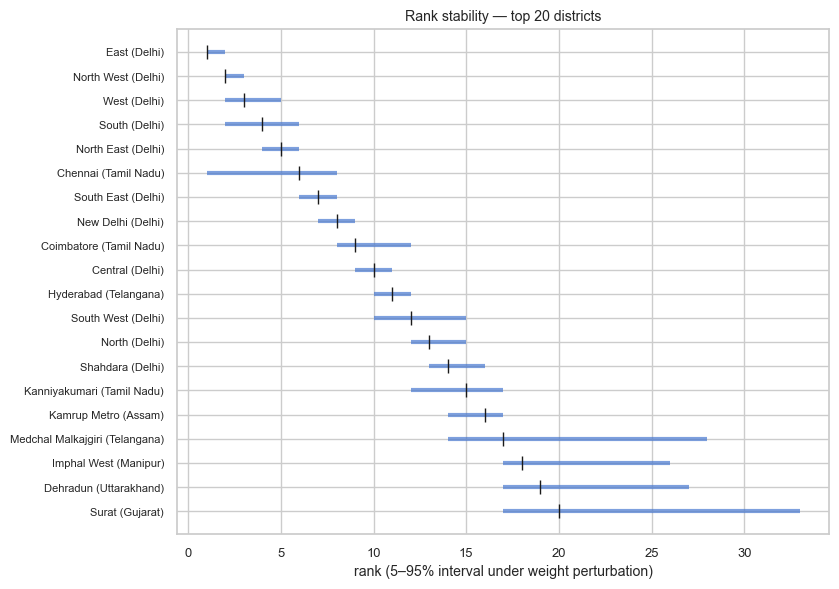

In [20]:
t20 = scores.join(meta).nsmallest(20, 'rank_overall')
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.hlines(y=range(len(t20)), xmin=t20['rank_lo_p5'], xmax=t20['rank_hi_p95'],
          color='#4878d0', lw=3, alpha=.7)
ax.plot(t20['rank_overall'], range(len(t20)), 'k|', ms=10)
ax.set_yticks(range(len(t20)))
ax.set_yticklabels(t20['district_name'] + ' (' + t20['state_name'].str[:12] + ')', fontsize=8)
ax.invert_yaxis(); ax.set_xlabel('rank (5–95% interval under weight perturbation)')
ax.set_title('Rank stability — top 20 districts'); plt.tight_layout(); plt.show()

## Phase 5 — Segmentation (k-means on pillar scores)

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(pillar_scores)
Zs = scaler.transform(pillar_scores)
sil = {k: silhouette_score(Zs, KMeans(k, n_init=10, random_state=42).fit_predict(Zs))
       for k in range(3, 9)}
k_best = max(sil, key=sil.get)
print('silhouette by k:', {k: round(v, 3) for k, v in sil.items()}, '| chosen k =', k_best)
km = KMeans(k_best, n_init=25, random_state=42).fit(Zs)
scores['cluster'] = km.labels_
prof = pillar_scores.groupby(km.labels_).mean().round(1)
prof['n'] = pd.Series(km.labels_).value_counts().sort_index().values
prof

I0718 09:39:40.588490 4612778 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(78, generation: 1)


silhouette by k: {3: 0.224, 4: 0.184, 5: 0.181, 6: 0.181, 7: 0.168, 8: 0.173} | chosen k = 3


,P1_scale,P2_chronic,P2_acute,P3_access,P4_afford,P5_momentum,n
0,32.8,44.2,29.2,48.4,57.0,40.8,200
1,45.9,41.4,30.1,63.8,63.5,37.8,195
2,43.7,33.2,41.6,42.9,39.9,42.6,303


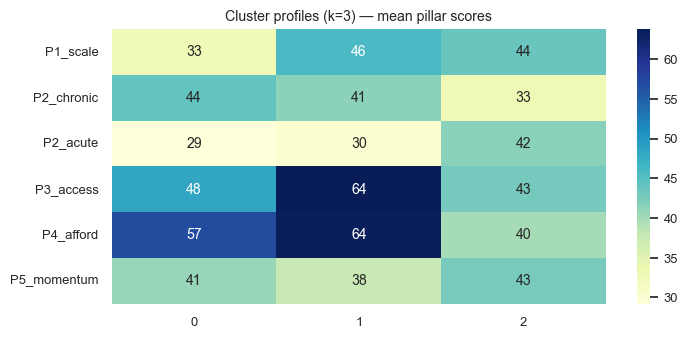

saved -> Saved_models/segmentation_kmeans.joblib


In [22]:
fig, ax = plt.subplots(figsize=(7.5, 3.5))
sns.heatmap(prof.drop(columns='n').T, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax)
ax.set_title(f'Cluster profiles (k={k_best}) — mean pillar scores')
plt.tight_layout(); plt.show()
joblib.dump({'scaler': scaler, 'kmeans': km}, SAVED / 'segmentation_kmeans.joblib')
print('saved -> Saved_models/segmentation_kmeans.joblib')

## Phase 6 — Multi-model comparison A: proxy-demand validation
Target = revealed private-market demand proxy (z-mean of TB private share & private hospitals per lakh). **Leakage control:** the supply pillar (P3) and the target's own components are excluded from features.

**Honest expectation-setting:** this proxy is *noisy* (two weakly related revealed-demand signals), so R² will be modest — the validation question is whether pillars carry *any* independent demand signal and whether the importance ordering is economically sensible, not whether R² is high. With paid IQVIA/AWACS sales data this validation would sharpen substantially; that limitation is stated in the deck.

In [23]:
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

proxy_df = base[['tb_private_share', 'hosp_private_per_lakh']].dropna()
proxy = ((proxy_df - proxy_df.mean()) / proxy_df.std()).mean(axis=1)
Xml = pillar_scores.drop(columns=['P3_access']).loc[proxy.index]
yml = proxy
print(f'ML set: {len(yml)} districts, features: {list(Xml.columns)}')

MODELS = {
 'Linear': LinearRegression(),
 'Ridge': Ridge(alpha=1.0),
 'Lasso': Lasso(alpha=0.01, max_iter=20000),
 'RandomForest': RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=42),
 'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=3,
                                               learning_rate=.05, random_state=42),
}
cv = KFold(5, shuffle=True, random_state=42)
res = []
for name, m in MODELS.items():
    r = cross_validate(m, Xml, yml, cv=cv,
                       scoring=('r2', 'neg_root_mean_squared_error',
                                'neg_mean_absolute_error'))
    res.append({'model': name, 'cv_R2': r['test_r2'].mean(),
                'cv_RMSE': -r['test_neg_root_mean_squared_error'].mean(),
                'cv_MAE': -r['test_neg_mean_absolute_error'].mean()})
res_a = pd.DataFrame(res).set_index('model').sort_values('cv_R2', ascending=False).round(3)
res_a

ML set: 569 districts, features: ['P1_scale', 'P2_chronic', 'P2_acute', 'P4_afford', 'P5_momentum']


,cv_R2,cv_RMSE,cv_MAE
model,,,
Lasso,0.225,0.634,0.408
Ridge,0.224,0.634,0.408
Linear,0.224,0.634,0.408
RandomForest,0.134,0.670,0.429
GradientBoosting,0.052,0.697,0.425


winner: Lasso | holdout R2=0.109 RMSE=0.855 MAE=0.431


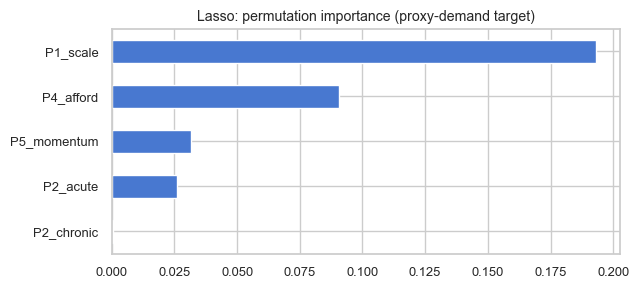

saved 5 models + meta -> Saved_models/


In [24]:
best_a_name = res_a.index[0]
Xtr, Xte, ytr, yte = train_test_split(Xml, yml, test_size=.25, random_state=42)
best_a = MODELS[best_a_name].fit(Xtr, ytr)
pred = best_a.predict(Xte)
print(f'winner: {best_a_name} | holdout R2={r2_score(yte, pred):.3f} '
      f'RMSE={mean_squared_error(yte, pred)**.5:.3f} MAE={mean_absolute_error(yte, pred):.3f}')
from sklearn.inspection import permutation_importance
pi = permutation_importance(best_a, Xte, yte, n_repeats=30, random_state=42)
imp = pd.Series(pi.importances_mean, index=Xml.columns).sort_values()
fig, ax = plt.subplots(figsize=(6.5, 3))
imp.plot.barh(ax=ax, color='#4878d0')
ax.set_title(f'{best_a_name}: permutation importance (proxy-demand target)')
plt.tight_layout(); plt.show()
for name, m in MODELS.items():
    joblib.dump(m.fit(Xml, yml), SAVED / f'proxy_demand_{name.lower()}.joblib')
joblib.dump({'winner': best_a_name, 'metrics': res_a.to_dict(),
             'features': list(Xml.columns)}, SAVED / 'proxy_demand_meta.joblib')
print('saved 5 models + meta -> Saved_models/')

## Phase 6b — Multi-model comparison B: MAI surrogate (explainability)
Predicts `mai_overall` from **raw indicators**. Circular by construction (stated honestly): its value is explainability — showing which raw indicators drive the composite — not validation.

In [25]:
ys = scores['mai_overall']
Xs2 = X.loc[ys.index]
res2 = []
for name, m in MODELS.items():
    r = cross_validate(m, Xs2, ys, cv=cv, scoring=('r2', 'neg_root_mean_squared_error'))
    res2.append({'model': name, 'cv_R2': r['test_r2'].mean(),
                 'cv_RMSE': -r['test_neg_root_mean_squared_error'].mean()})
res_b = pd.DataFrame(res2).set_index('model').sort_values('cv_R2', ascending=False).round(3)
best_b_name = res_b.index[0]
best_b = MODELS[best_b_name].fit(Xs2, ys)
joblib.dump(best_b, SAVED / f'mai_surrogate_{best_b_name.lower()}.joblib')
print('winner:', best_b_name, '| saved -> Saved_models/')
res_b

winner: Lasso | saved -> Saved_models/


,cv_R2,cv_RMSE
model,,
Lasso,0.951,0.963
Ridge,0.951,0.964
Linear,0.951,0.964
GradientBoosting,0.913,1.274
RandomForest,0.850,1.667


## Phase 7 — Publish `mai_scores` + `mai_runs` to Firestore

In [26]:
out = scores.join(meta).join(pillar_scores.round(2))
batch = db.batch(); n = 0
for code_, r in out.iterrows():
    doc = {
      'district_name': r['district_name'], 'state_name': r['state_name'],
      'overall_score': round(float(r['mai_overall']), 2),
      'overall_rank': int(r['rank_overall']), 'tier': str(r['tier']),
      'chronic_score': round(float(r['mai_chronic']), 2),
      'chronic_rank': int(r['rank_chronic']),
      'acute_score': round(float(r['mai_acute']), 2),
      'acute_rank': int(r['rank_acute']),
      'current_vs_future': {'current_score': round(float(r['mai_current']), 2),
                            'projected_score': round(float(r['mai_future']), 2),
                            'growth_flag': bool(r['growth_flag'])},
      'rank_interval_p5_p95': [int(r['rank_lo_p5']), int(r['rank_hi_p95'])],
      'pillar_scores': {p: round(float(r[p]), 2) for p in PILLARS},
      'cluster': int(r['cluster']),
      'model_version': MODEL_VERSION,
    }
    batch.set(db.collection('mai_scores').document(str(code_)), doc)
    n += 1
    if n % 400 == 0:
        batch.commit(); batch = db.batch()
batch.commit()
print(f'published {n} docs -> mai_scores')

db.collection('mai_runs').document(MODEL_VERSION).set({
  'method': 'winsorize(2.5/97.5 on JRC-flagged) -> min-max 0-100 directional -> '
            'pillar means -> business weights -> weighted arithmetic mean; '
            'geometric + PCA/entropy variants as robustness',
  'weights': W_BUSINESS, 'weights_pca': {k: float(v) for k, v in w_pca.items()},
  'weights_entropy': {k: float(v) for k, v in w_ent.items()},
  'n_districts': n, 'n_indicators': len(ALL_IND),
  'imputed_cells_pct': round(n_imp / X.size * 100, 2),
  'top50_stability_pct': round(stab * 100, 1),
  'ml_proxy_winner': best_a_name, 'ml_proxy_cv_r2': float(res_a.iloc[0]['cv_R2']),
  'ml_surrogate_winner': best_b_name,
  'segmentation_k': int(k_best),
  'created_at': firestore.SERVER_TIMESTAMP, 'author': 'MAI_analysis.ipynb',
})
print('published run doc -> mai_runs/' + MODEL_VERSION)

published 698 docs -> mai_scores
published run doc -> mai_runs/mai_v1_2026-07-17


## Summary
- Crosswalk, feature matrix, coverage & imputation logs → `data/interim/`
- Composite MAI (overall/chronic/acute + current/future + tiers + rank intervals) → **Firestore `mai_scores`**
- Reproducibility doc → `mai_runs`
- Five proxy-demand models + surrogate + k-means → `Saved_models/*.joblib`
- Statistical evidence: normality/outlier screen, paired NFHS-4→5 tests, pillar coherence, region ANOVA, MC rank stability.